# Project 1: EDA on Retail Sales Data
**Oasis Infobyte - Level 1**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Create Dataset

In [9]:
np.random.seed(42)
n = 1000
categories = ['Electronics','Clothing','Groceries','Furniture','Sports']
genders = ['Male','Female']
age_groups = ['18-25','26-35','36-45','46-60','60+']

df = pd.DataFrame({
    'Date': np.random.choice(pd.date_range('2022-01-01','2023-12-31'), n),
    'Transaction_ID': range(1001, 1001+n),
    'Customer_ID': np.random.randint(100, 500, n),
    'Age_Group': np.random.choice(age_groups, n),
    'Gender': np.random.choice(genders, n),
    'Product_Category': np.random.choice(categories, n, p=[0.25,0.20,0.30,0.10,0.15]),
    'Quantity': np.random.randint(1, 10, n),
    'Price_per_Unit': np.round(np.random.uniform(50, 5000, n), 2),
})
df['Total_Amount'] = df['Quantity'] * df['Price_per_Unit']
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Num'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.loc[np.random.choice(df.index,30), 'Age_Group'] = np.nan
df.loc[np.random.choice(df.index,20), 'Price_per_Unit'] = np.nan
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1000, 11)


,Date,Transaction_ID,Customer_ID,Age_Group,Gender,Product_Category,Quantity,Price_per_Unit,Total_Amount,Month_Num,Year
0,2022-04-13,1001,428,26-35,Female,Electronics,2,2525.29,5050.58,4,2022
1,2023-03-12,1002,372,36-45,Female,Groceries,2,3390.72,6781.44,3,2023
2,2022-09-28,1003,364,36-45,Female,Furniture,5,1233.38,6166.90,9,2022
3,2022-04-17,1004,498,26-35,Female,Electronics,5,3802.30,19011.50,4,2022
4,2022-03-13,1005,137,60+,Female,Sports,7,3812.03,26684.21,3,2022


## Step 2: Data Cleaning

In [10]:
print('Missing before:', df.isnull().sum().sum())
df['Age_Group'].fillna(df['Age_Group'].mode()[0], inplace=True)
df['Price_per_Unit'].fillna(df['Price_per_Unit'].median(), inplace=True)
df['Total_Amount'] = df['Quantity'] * df['Price_per_Unit']
print('Missing after:', df.isnull().sum().sum())
df.describe()

Missing before: 50
Missing after: 0


,Date,Transaction_ID,Customer_ID,Quantity,Price_per_Unit,Total_Amount,Month_Num,Year
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2022-12-25 22:42:14.400000256,1500.500000,300.118000,5.074000,2516.969580,12704.323970,6.372000,2022.498000
min,2022-01-01 00:00:00,1001.000000,100.000000,1.000000,51.120000,102.040000,1.000000,2022.000000
25%,2022-06-16 18:00:00,1250.750000,196.750000,3.000000,1327.042500,4123.722500,3.000000,2022.000000
50%,2022-12-31 00:00:00,1500.500000,301.000000,5.000000,2444.215000,10622.630000,6.000000,2022.000000
75%,2023-07-02 00:00:00,1750.250000,403.250000,7.000000,3761.742500,18819.490000,9.000000,2023.000000
max,2023-12-31 00:00:00,2000.000000,499.000000,9.000000,4994.030000,44065.890000,12.000000,2023.000000
std,NaN,288.819436,117.750496,2.547354,1417.109139,10078.577659,3.477025,0.500246


## Step 3: Descriptive Statistics

In [11]:
print(f"Total Revenue: Rs.{df['Total_Amount'].sum():,.2f}")
print(f"Avg Transaction: Rs.{df['Total_Amount'].mean():,.2f}")
print(f"Total Transactions: {len(df)}")
print(f"Unique Customers: {df['Customer_ID'].nunique()}")

Total Revenue: Rs.12,704,323.97
Avg Transaction: Rs.12,704.32
Total Transactions: 1000
Unique Customers: 364


## Step 4: Time Series Analysis

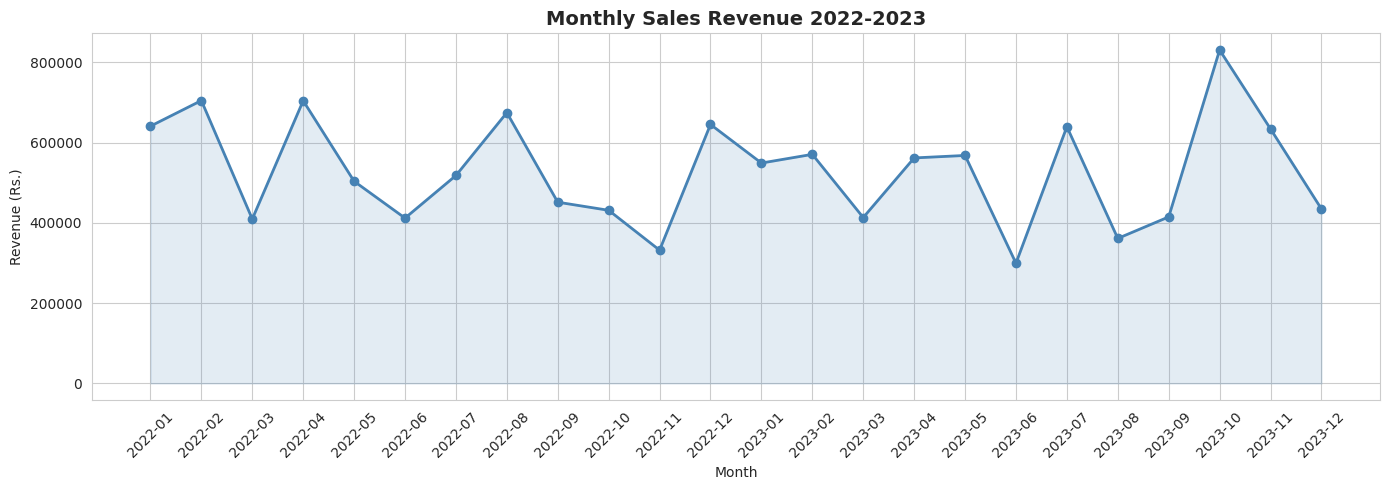

In [12]:
monthly = df.groupby(['Year','Month_Num'])['Total_Amount'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month_Num'].astype(str).str.zfill(2)
monthly = monthly.sort_values('Period')

plt.figure(figsize=(14,5))
plt.plot(monthly['Period'], monthly['Total_Amount'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly)), monthly['Total_Amount'], alpha=0.15, color='steelblue')
plt.title('Monthly Sales Revenue 2022-2023', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs.)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 5: Category & Demographics Analysis

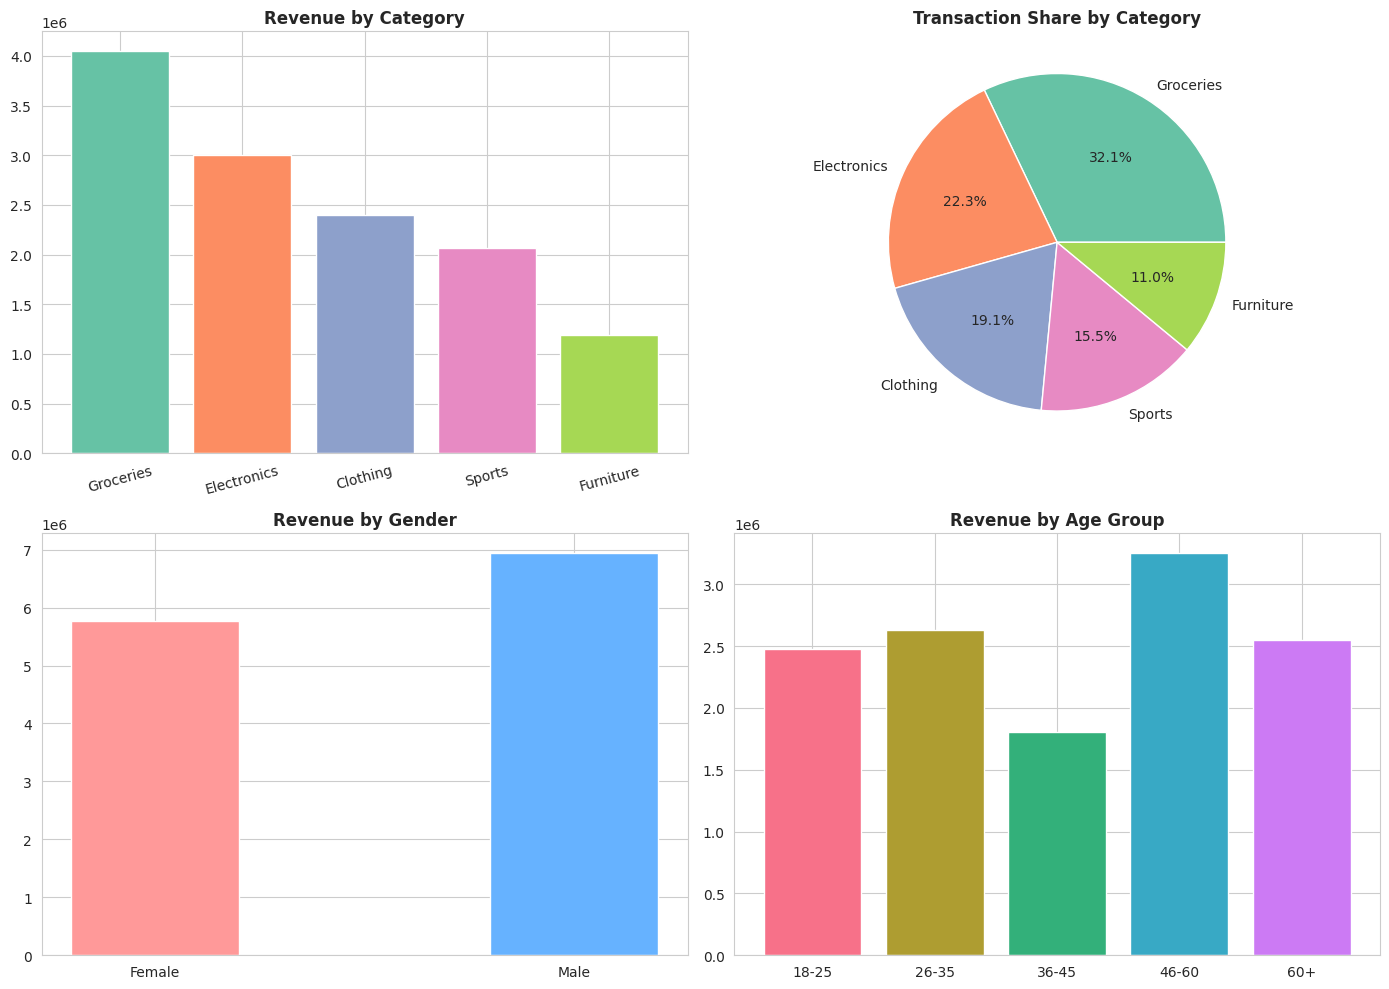

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

cat_rev = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False)
axes[0,0].bar(cat_rev.index, cat_rev.values, color=sns.color_palette('Set2',5))
axes[0,0].set_title('Revenue by Category', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=15)

cat_count = df['Product_Category'].value_counts()
axes[0,1].pie(cat_count.values, labels=cat_count.index, autopct='%1.1f%%', colors=sns.color_palette('Set2',5))
axes[0,1].set_title('Transaction Share by Category', fontweight='bold')

gender_rev = df.groupby('Gender')['Total_Amount'].sum()
axes[1,0].bar(gender_rev.index, gender_rev.values, color=['#FF9999','#66B2FF'], width=0.4)
axes[1,0].set_title('Revenue by Gender', fontweight='bold')

age_rev = df.groupby('Age_Group')['Total_Amount'].sum().reindex(['18-25','26-35','36-45','46-60','60+'])
axes[1,1].bar(age_rev.index, age_rev.values, color=sns.color_palette('husl',5))
axes[1,1].set_title('Revenue by Age Group', fontweight='bold')

plt.tight_layout()
plt.savefig('analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 6: Heatmap & Recommendations

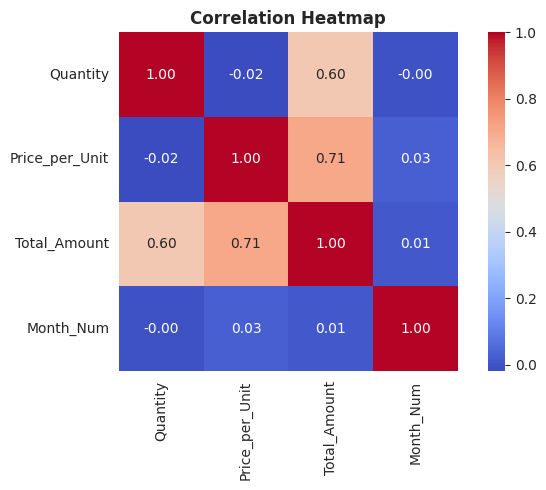

Top Category: Groceries
Top Age Group: 46-60
Recommendation: Focus marketing on Groceries targeting 46-60 customers


In [14]:
plt.figure(figsize=(7,5))
corr = df[['Quantity','Price_per_Unit','Total_Amount','Month_Num']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

top_cat = df.groupby('Product_Category')['Total_Amount'].sum().idxmax()
top_age = df.groupby('Age_Group')['Total_Amount'].sum().idxmax()
print(f"Top Category: {top_cat}")
print(f"Top Age Group: {top_age}")
print("Recommendation: Focus marketing on", top_cat, "targeting", top_age, "customers")